In [124]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from src.neural_decoder.model import *

In [125]:
# modelName, log_dir = "Baseline", './speechLogs/speechBaseline4'
# modelName, log_dir = "Optimized Baseline", './speechLogs/optimizedBaseline_withLog'
# modelName, log_dir = "Optimized Baseline w/o Log Tfm", './speechLogs/optimizedBaseline_withoutLog' # Ablation study
modelName, log_dir = "Optimized w/o Layer Norm", './speechLogs/optimizedBaseline_04_15_01' # Ablation study
# modelName, log_dir = "Optimized w Head", './speechLogs/optimizedBaselineHead' # Ablation study
# modelName, log_dir = "Optimized Unidirectional", './speechLogs/optimizedUnidirectional' # Ablation study
# modelName, log_dir = "Transformer w Sin Emb", './speechLogs/Transformer_SinEmb'
# modelName, log_dir = "Transformer w Learned Emb", './speechLogs/Transformer_Learned'
# modelName, log_dir = "Transformer w 4 heads", './speechLogs/Transformer_4heads'
# modelName, log_dir = "Hybrid", './speechLogs/Hybrid'
# modelName, log_dir = "Transition", './speechLogs/Transition'
modelName, log_dir = "Markov Transition", './speechLogs/MarkovTransition_05_16_52'
modelName, log_dir = "Ensemble", './speechLogs/Ensemble'


# take a look at the arguments
args = None

with open(os.path.join(log_dir, 'args'), 'rb') as f:
    args = pickle.load(f)
with open(os.path.join(log_dir, 'trainingStats'), 'rb') as f:
    history_log = pickle.load(f)


In [126]:
baseline_log_dir = './speechLogs/speechBaseline4'
# take a look at the arguments
baseline_args = None

with open(os.path.join(baseline_log_dir, 'args'), 'rb') as f:
    baseline_args = pickle.load(f)
with open(os.path.join(baseline_log_dir, 'trainingStats'), 'rb') as f:
    baseline_history_log = pickle.load(f)

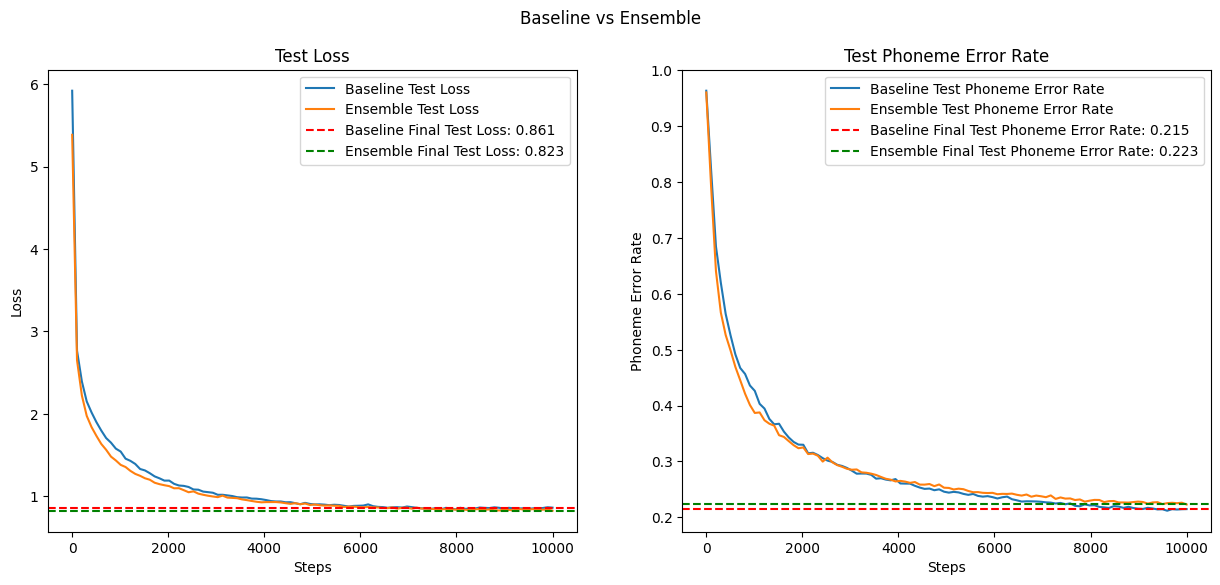

In [127]:
# Visualize the history progress
# Get the baseline data
baseline_total_steps = baseline_args["nBatch"]
baseline_nSamples = len(baseline_history_log['testLoss'])
baseline_testLoss = baseline_history_log['testLoss']
baseline_testCER = baseline_history_log['testCER']

# Get the real data
total_steps = args["nBatch"]
nSamples = len(history_log['testLoss'])
testLoss = history_log['testLoss']
testCER = history_log['testCER']

# Using 2 subplots plot the baseline vs real data
plt.figure(figsize=(15, 6))
# set a figure title
plt.suptitle(f'Baseline vs {modelName}')
plt.subplot(1, 2, 1)
plt.plot(np.linspace(1, baseline_total_steps, baseline_nSamples), baseline_testLoss, label='Baseline Test Loss')
plt.plot(np.linspace(1, total_steps, nSamples), testLoss, label=f'{modelName} Test Loss')
plt.axhline(y=baseline_testLoss[-1], color='r', linestyle='--', label=f'Baseline Final Test Loss: {baseline_testLoss[-1]:.3f}')
plt.axhline(y=testLoss[-1], color='g', linestyle='--', label=f'{modelName} Final Test Loss: {testLoss[-1]:.3f}')
# add a faint vline at 1000 steps
# plt.axvline(x=1000, color='b', linestyle='--', label='Learning Rate Decay', alpha=0.25)
# plt.ylim(0, 3*baseline_testLoss[-1])
plt.title('Test Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.linspace(1, baseline_total_steps, baseline_nSamples), baseline_testCER, label='Baseline Test Phoneme Error Rate')
plt.plot(np.linspace(1, total_steps, nSamples), testCER, label=f'{modelName} Test Phoneme Error Rate')
plt.axhline(y=baseline_testCER[-1], color='r', linestyle='--', label=f'Baseline Final Test Phoneme Error Rate: {baseline_testCER[-1]:.3f}')
plt.axhline(y=testCER[-1], color='g', linestyle='--', label=f'{modelName} Final Test Phoneme Error Rate: {testCER[-1]:.3f}')
# plt.axvline(x=1000, color='b', linestyle='--', label='Learning Rate Decay', alpha=0.25)
# plt.ylim(0, 0.5)
plt.title('Test Phoneme Error Rate')
plt.xlabel('Steps')
plt.ylabel('Phoneme Error Rate')
plt.legend()
plt.show()